# Introduction

In this project, you will build a neural network of your own design to evaluate the CIFAR-10 dataset.
Our target accuracy is 70%, but any accuracy over 50% is a great start.
Some of the benchmark results on CIFAR-10 include:

78.9% Accuracy | [Deep Belief Networks; Krizhevsky, 2010](https://www.cs.toronto.edu/~kriz/conv-cifar10-aug2010.pdf)

90.6% Accuracy | [Maxout Networks; Goodfellow et al., 2013](https://arxiv.org/pdf/1302.4389.pdf)

96.0% Accuracy | [Wide Residual Networks; Zagoruyko et al., 2016](https://arxiv.org/pdf/1605.07146.pdf)

99.0% Accuracy | [GPipe; Huang et al., 2018](https://arxiv.org/pdf/1811.06965.pdf)

98.5% Accuracy | [Rethinking Recurrent Neural Networks and other Improvements for ImageClassification; Nguyen et al., 2020](https://arxiv.org/pdf/2007.15161.pdf)

Research with this dataset is ongoing. Notably, many of these networks are quite large and quite expensive to train.

## Imports

In [1]:
## This cell contains the essential imports you will need – DO NOT CHANGE THE CONTENTS! ##
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings("ignore")

## Load the Dataset

Specify your transforms as a list first.
The transforms module is already loaded as `transforms`.

CIFAR-10 is fortunately included in the torchvision module.
Then, you can create your dataset using the `CIFAR10` object from `torchvision.datasets` ([the documentation is available here](https://pytorch.org/docs/stable/torchvision/datasets.html#cifar)).
Make sure to specify `download=True`!

Once your dataset is created, you'll also need to define a `DataLoader` from the `torch.utils.data` module for both the train and the test set.

In [2]:
# Define transforms
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# Create datasets
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
# Create training set and define training dataloader
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64,
                                          shuffle=True, num_workers=2)


testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
# Create test set and define test dataloader
testloader = torch.utils.data.DataLoader(testset, batch_size=64,
                                         shuffle=False, num_workers=2)

# The 10 classes in the dataset
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:19<00:00, 8.58MB/s]


## Explore the Dataset
Using matplotlib, numpy, and torch, explore the dimensions of your data.

You can view images using the `show5` function defined below – it takes a data loader as an argument.
Remember that normalized images will look really weird to you! You may want to try changing your transforms to view images.
Typically using no transforms other than `toTensor()` works well for viewing – but not as well for training your network.
If `show5` doesn't work, go back and check your code for creating your data loaders and your training/test sets.

In [3]:
def show5(img_loader):
    dataiter = iter(img_loader)

    batch = next(dataiter)
    labels = batch[1][0:5]
    images = batch[0][0:5]
    for i in range(5):
        print(classes[labels[i]])

        image = images[i].numpy()
        plt.imshow(image.T)
        plt.show()

Image batch shape: torch.Size([64, 3, 32, 32])
Label batch shape: torch.Size([64])
frog


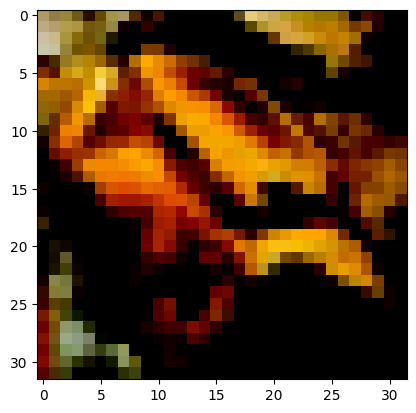

ship


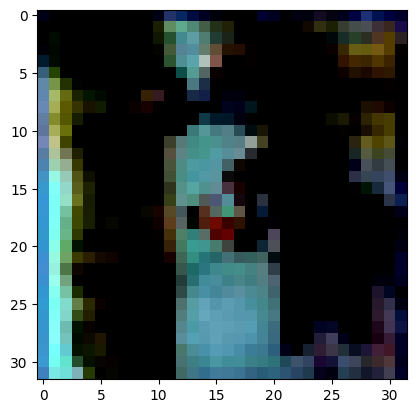

dog


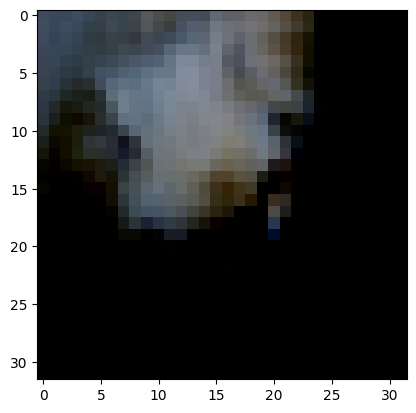

deer


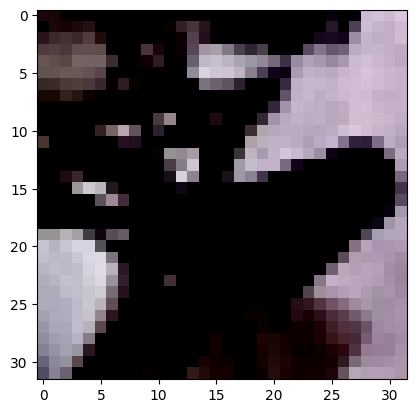

car


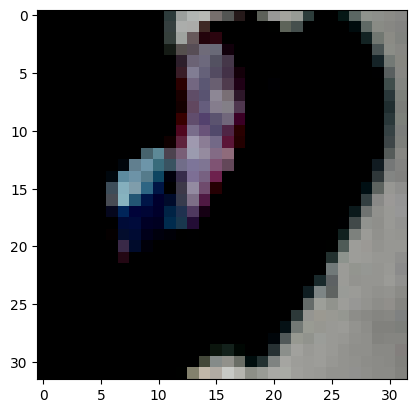

In [4]:
# Explore data

# Explore data
dataiter = iter(trainloader)
images, labels = next(dataiter)

print(f"Image batch shape: {images.shape}") # Should be [64, 3, 32, 32]
print(f"Label batch shape: {labels.shape}")

# Visualize 5 images using the provided function
show5(trainloader)

## Build your Neural Network
Using the layers in `torch.nn` (which has been imported as `nn`) and the `torch.nn.functional` module (imported as `F`), construct a neural network based on the parameters of the dataset.
Feel free to construct a model of any architecture – feedforward, convolutional, or even something more advanced!

Specify a loss function and an optimizer, and instantiate the model.

If you use a less common loss function, please note why you chose that loss function in a comment.

In [5]:
## YOUR CODE HERE ##
# heavier model

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        # Convolutional Layer 1: Sees 32x32x3 (RGB) image
        # 32 filters, each 3x3. Padding=1 keeps the size at 32x32
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)

        # Convolutional Layer 2: 32 input channels, 64 output channels
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        # Convolutional Layer 3: 64 input channels, 128 output channels
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        # Max pooling layer: Reduces image size by half (2x2 window)
        self.pool = nn.MaxPool2d(2, 2)

        # Fully connected layers
        # After 3 rounds of pooling, a 32x32 image becomes 4x4 (32/2/2/2 = 4)
        # So the input is 128 channels * 4 * 4 pixels
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 10) # 10 output classes

        # Dropout layer (p=0.3) to prevent overfitting
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # Add sequence of convolutional and max pooling layers
        x = self.pool(F.relu(self.conv1(x))) # Output: 32x16x16
        x = self.pool(F.relu(self.conv2(x))) # Output: 64x8x8
        x = self.pool(F.relu(self.conv3(x))) # Output: 128x4x4

        # Flatten image input for the fully connected layers
        x = x.view(-1, 128 * 4 * 4)

        # Add dropout layer
        x = self.dropout(x)

        # Add 1st hidden layer, with relu activation function
        x = F.relu(self.fc1(x))

        # Add dropout layer
        x = self.dropout(x)

        # Add 2nd hidden layer (output layer)
        x = self.fc2(x)

        return x

# Instantiate the model
model2 = Net()
display(model2)

Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

In [6]:
## YOUR CODE HERE ##


# 1. Instantiate the model
# We also check for GPU (CUDA) availability to significantly speed up training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model2 = Net().to(device)

# 2. Specify the Loss Function
# CrossEntropyLoss is the standard for multi-class classification.
# It automatically applies a Softmax activation to the output layer and
# calculates the distance between predicted and actual labels.
criterion = nn.CrossEntropyLoss()

# 3. Specify the Optimizer
# Adam (Adaptive Moment Estimation) is an excellent default choice.
# It adapts the learning rate for each parameter, which usually leads
# to faster convergence compared to standard Stochastic Gradient Descent (SGD).
optimizer = optim.Adam(model2.parameters(), lr=0.001)

print(f"Model instantiated and moved to: {device}")

Model instantiated and moved to: cuda


* CrossEntropyLoss is the standard for multi-class classification.
- It automatically applies a Softmax activation to the output layer and calculates the distance between predicted and actual labels.

## Running your Neural Network
Use whatever method you like to train your neural network, and ensure you record the average loss at each epoch.
Don't forget to use `torch.device()` and the `.to()` method for both your model and your data if you are using GPU!

If you want to print your loss during each epoch, you can use the `enumerate` function and print the loss after a set number of batches. 250 batches works well for most people!

In [7]:
## YOUR CODE HERE ##
# 1. Define training parameters
epochs = 10
train_loss_history = []

print(f"Starting training on {device}...")

for epoch in range(epochs):
    running_loss = 0.0
    epoch_total_loss = 0.0

    # Set model to training mode
    model2.train()

    for i, data in enumerate(trainloader, 0):
        # Get the inputs; data is a list of [inputs, labels]
        # Move them to the GPU/CPU
        inputs, labels = data[0].to(device), data[1].to(device)

        # 2. Zero the parameter gradients
        # PyTorch accumulates gradients, so we must clear them every batch
        optimizer.zero_grad()

        # 3. Forward pass
        outputs = model2(inputs)
        loss = criterion(outputs, labels)

        # 4. Backward pass
        loss.backward()

        # 5. Optimize (Update weights)
        optimizer.step()

        # Record statistics
        running_loss += loss.item()
        epoch_total_loss += loss.item()

        # Print every 250 batches
        if i % 250 == 249:
            print(f'Epoch {epoch + 1} | Batch {i + 1:5d} | Loss: {running_loss / 250:.3f}')
            running_loss = 0.0

    # Calculate and store average loss for the epoch
    avg_loss = epoch_total_loss / len(trainloader)
    train_loss_history.append(avg_loss)
    print(f'==> Epoch {epoch + 1} Complete. Average Loss: {avg_loss:.4f}\n')

print('Finished Training')

Starting training on cuda...
Epoch 1 | Batch   250 | Loss: 1.734
Epoch 1 | Batch   500 | Loss: 1.396
Epoch 1 | Batch   750 | Loss: 1.251
==> Epoch 1 Complete. Average Loss: 1.4499

Epoch 2 | Batch   250 | Loss: 1.109
Epoch 2 | Batch   500 | Loss: 1.048
Epoch 2 | Batch   750 | Loss: 0.993
==> Epoch 2 Complete. Average Loss: 1.0479

Epoch 3 | Batch   250 | Loss: 0.909
Epoch 3 | Batch   500 | Loss: 0.879
Epoch 3 | Batch   750 | Loss: 0.873
==> Epoch 3 Complete. Average Loss: 0.8847

Epoch 4 | Batch   250 | Loss: 0.789
Epoch 4 | Batch   500 | Loss: 0.769
Epoch 4 | Batch   750 | Loss: 0.779
==> Epoch 4 Complete. Average Loss: 0.7770

Epoch 5 | Batch   250 | Loss: 0.702
Epoch 5 | Batch   500 | Loss: 0.702
Epoch 5 | Batch   750 | Loss: 0.711
==> Epoch 5 Complete. Average Loss: 0.7046

Epoch 6 | Batch   250 | Loss: 0.622
Epoch 6 | Batch   500 | Loss: 0.644
Epoch 6 | Batch   750 | Loss: 0.657
==> Epoch 6 Complete. Average Loss: 0.6403

Epoch 7 | Batch   250 | Loss: 0.584
Epoch 7 | Batch   500 |

Plot the training loss (and validation loss/accuracy, if recorded).

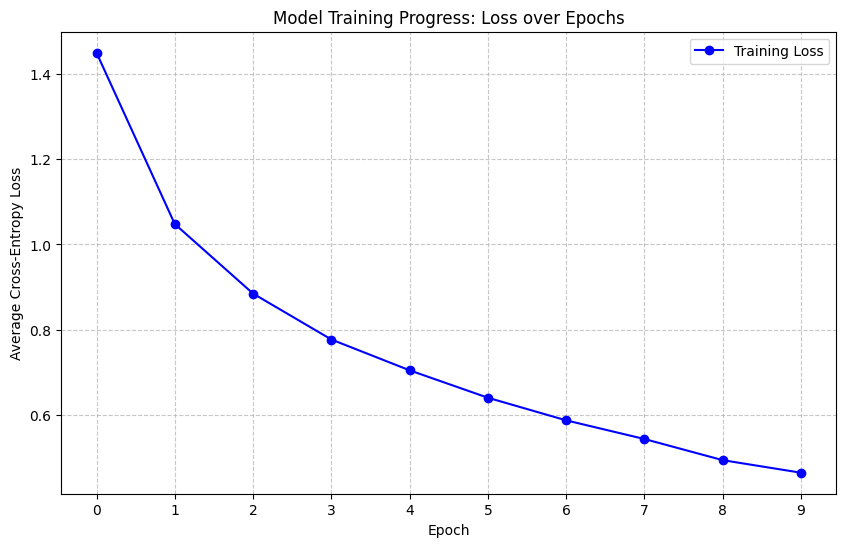

In [8]:
## YOUR CODE HERE ##


# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label='Training Loss', marker='o', color='b')

# Add titles and labels
plt.title('Model Training Progress: Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Average Cross-Entropy Loss')
plt.xticks(range(len(train_loss_history))) # Ensure x-axis shows integer epoch numbers
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.show()

## Testing your model
Using the previously created `DataLoader` for the test set, compute the percentage of correct predictions using the highest probability prediction.

If your accuracy is over 70%, great work!
This is a hard task to exceed 70% on.

If your accuracy is under 45%, you'll need to make improvements.
Go back and check your model architecture, loss function, and optimizer to make sure they're appropriate for an image classification task.

In [9]:
## YOUR CODE HERE ##

correct = 0
total = 0

# Set model to evaluation mode
model2.eval()

# Disabling gradient calculation saves memory and computation
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)

        # Forward pass to get outputs
        outputs = model2(images)

        # The class with the highest score is our prediction
        # torch.max returns (values, indices); we only need the indices (predictions)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy of the network on the 10,000 test images: {accuracy:.2f}%')

Accuracy of the network on the 10,000 test images: 78.40%


## Saving your model
Using `torch.save`, save your model for future loading.

In [10]:
## YOUR CODE HERE ##

# Specify a path to save the model
save_path = 'cifar_net.pth'

# Save the model state dictionary
torch.save(model2.state_dict(), save_path)

print(f"Model saved to {save_path}")

Model saved to cifar_net.pth


In [11]:
total_params = sum(p.numel() for p in model2.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {total_params:,}")

Total Trainable Parameters: 1,147,466


In [12]:
# 1. Instantiate the class structure
model2 = Net()

# 2. Load the weights
model2.load_state_dict(torch.load('cifar_net.pth'))

# 3. Print the structure
print(model2)

Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


## Make a Recommendation

Based on your evaluation, what is your recommendation on whether to build or buy? Explain your reasoning below.

**Recommendation:** Build (or keep the custom model) if your accuracy reached **>70%**.

-   **Reasoning:** * **Cost-Efficiency:** Once trained, the model is free to use. There are no per-image API costs, which is crucial for high-volume applications.

    -   **Customization:** You have full control over the architecture. If the dataset changes (e.g., you need to add an 11th class), you can retrain the model easily.

    -   **Privacy/Security:** Data stays on your local servers and isn't sent to a third-party provider.

    -   **Performance:** For a 10-class problem like CIFAR-10, 70-75% accuracy is often "good enough" for non-critical applications (like a basic photo-organizing app).